In [4]:
from ultralytics import YOLO
from torchvision.io import read_image

from utils import display_images

In [ ]:
MODEL_PATH = 'yolo26n.pt'
IMAGE_PATH = 'testing.jpg'

CONFIDENCE_THRESHOLD = 0.7

In [6]:
print('Loading model...')
model = YOLO(MODEL_PATH)
print('Model loaded.')

Loading model...
Model loaded.


<Figure size 640x480 with 0 Axes>

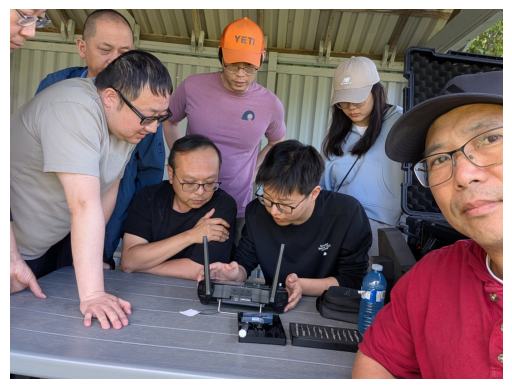

In [7]:
# Load image
image = read_image(IMAGE_PATH)
display_images(image.permute(1, 2, 0))

In [8]:
print('Running inference...')
results = model(IMAGE_PATH)
print('Inference done.')

Running inference...

image 1/1 /Users/guochaohe/projects/drones/tony-uav-bible/docs/ai-yolo/yolo26/testing.jpg: 480x640 8 persons, 1 bottle, 1 dining table, 41.6ms
Speed: 4.3ms preprocess, 41.6ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
Inference done.


In [19]:
results[0].show()

In [11]:
#results是一个集合，对于每一张图片，推理后的结果都放在result中
#对于单张图片，它的检测结果都放在result[0]
print(len(results))
for result in results:
    print(result)

1
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: '

tensor([0.8927, 0.8847, 0.8819, 0.8616, 0.8077, 0.7971, 0.7835, 0.3129, 0.3096, 0.3013])
tensor([ True,  True,  True,  True,  True,  True,  True, False, False, False])
tensor([[8.1418e+02, 9.2943e+02, 1.6813e+03, 2.0235e+03],
        [2.5187e+03, 4.6881e+02, 3.6453e+03, 2.7282e+03],
        [1.4357e+03, 9.5797e+02, 2.6836e+03, 2.2052e+03],
        [1.9716e+00, 2.6993e+02, 1.2122e+03, 2.3910e+03],
        [1.1010e+03, 6.0229e+01, 2.0498e+03, 1.5453e+03],
        [2.2924e+03, 3.4878e+02, 2.9252e+03, 1.6116e+03],
        [2.5627e+03, 1.8836e+03, 2.7957e+03, 2.4234e+03]])


<Figure size 640x480 with 0 Axes>

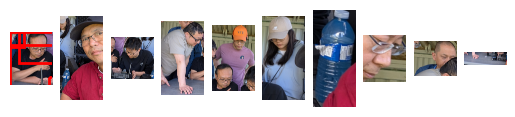

In [ ]:
boxes = []
roi_images = []
for result in results:
    # print(result.boxes)
    xyxy = result.boxes.xyxy
    confidences = result.boxes.conf
    masks = confidences > 0.7
    filtered_xyxy = xyxy[masks]
    print(confidences)
    print(masks)
    print(filtered_xyxy)
    # boxes.append(xyxy)
    for i, box in enumerate(filtered_xyxy):
        x1,y1,x2,y2 = box[:4].int()
        roi = image[:, y1:y2, x1:x2]
        roi_images.append(roi.permute(1, 2, 0))

display_images(roi_images, bboxes_list=boxes)